In [14]:
#first things first and following the international standardized priorities 
print("Hello Note!")

Hello Note!


In [15]:
import pandas as pd
#of course I begin with geting the dataset from the .csv file in the morning
df = pd.read_csv("../data/Housing.csv")
#let's take a quick look on what we're working with
df.head(10)
#after taking the priceless oportunity to follow the national tradition of looking over 999, American edition,
#    I have the highest pleasure the feel the ambiguity of understanding the measure units for area
#    square meters? square feets? planar projections of cheeseburgers?...

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [16]:
#in order to proceed with the dataset, stats are required
#info() method gives both the non-null rows and dtype for each column
df.info()
#every row seems valid according to each column

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [17]:
#nice, the dataset would beautifully fit on 39 3.5-inch floppy drives!

In [18]:
#for now, the string columns remain a certain mistery regarding what they describe
str_cols = df.select_dtypes(include=['str']).columns.tolist()
#we'll store the unique values for each str column in a dictionary (just in case)
str_col_vals = {}
for str_col in str_cols:
    str_col_vals[str_col] = df[str_col].unique()
    print(str_col)
    print(str_col_vals[str_col])
    print()
#bellow we can observe that most of the string columns represent yes/no responses (except furnishingstatus, it is a ternary state)

mainroad
<StringArray>
['yes', 'no']
Length: 2, dtype: str

guestroom
<StringArray>
['no', 'yes']
Length: 2, dtype: str

basement
<StringArray>
['no', 'yes']
Length: 2, dtype: str

hotwaterheating
<StringArray>
['no', 'yes']
Length: 2, dtype: str

airconditioning
<StringArray>
['yes', 'no']
Length: 2, dtype: str

prefarea
<StringArray>
['yes', 'no']
Length: 2, dtype: str

furnishingstatus
<StringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str



In [19]:
#additionally, let's get the description of the numerical columns
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'area'}>],
       [<Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>],
       [<Axes: title={'center': 'stories'}>,
        <Axes: title={'center': 'parking'}>]], dtype=object)

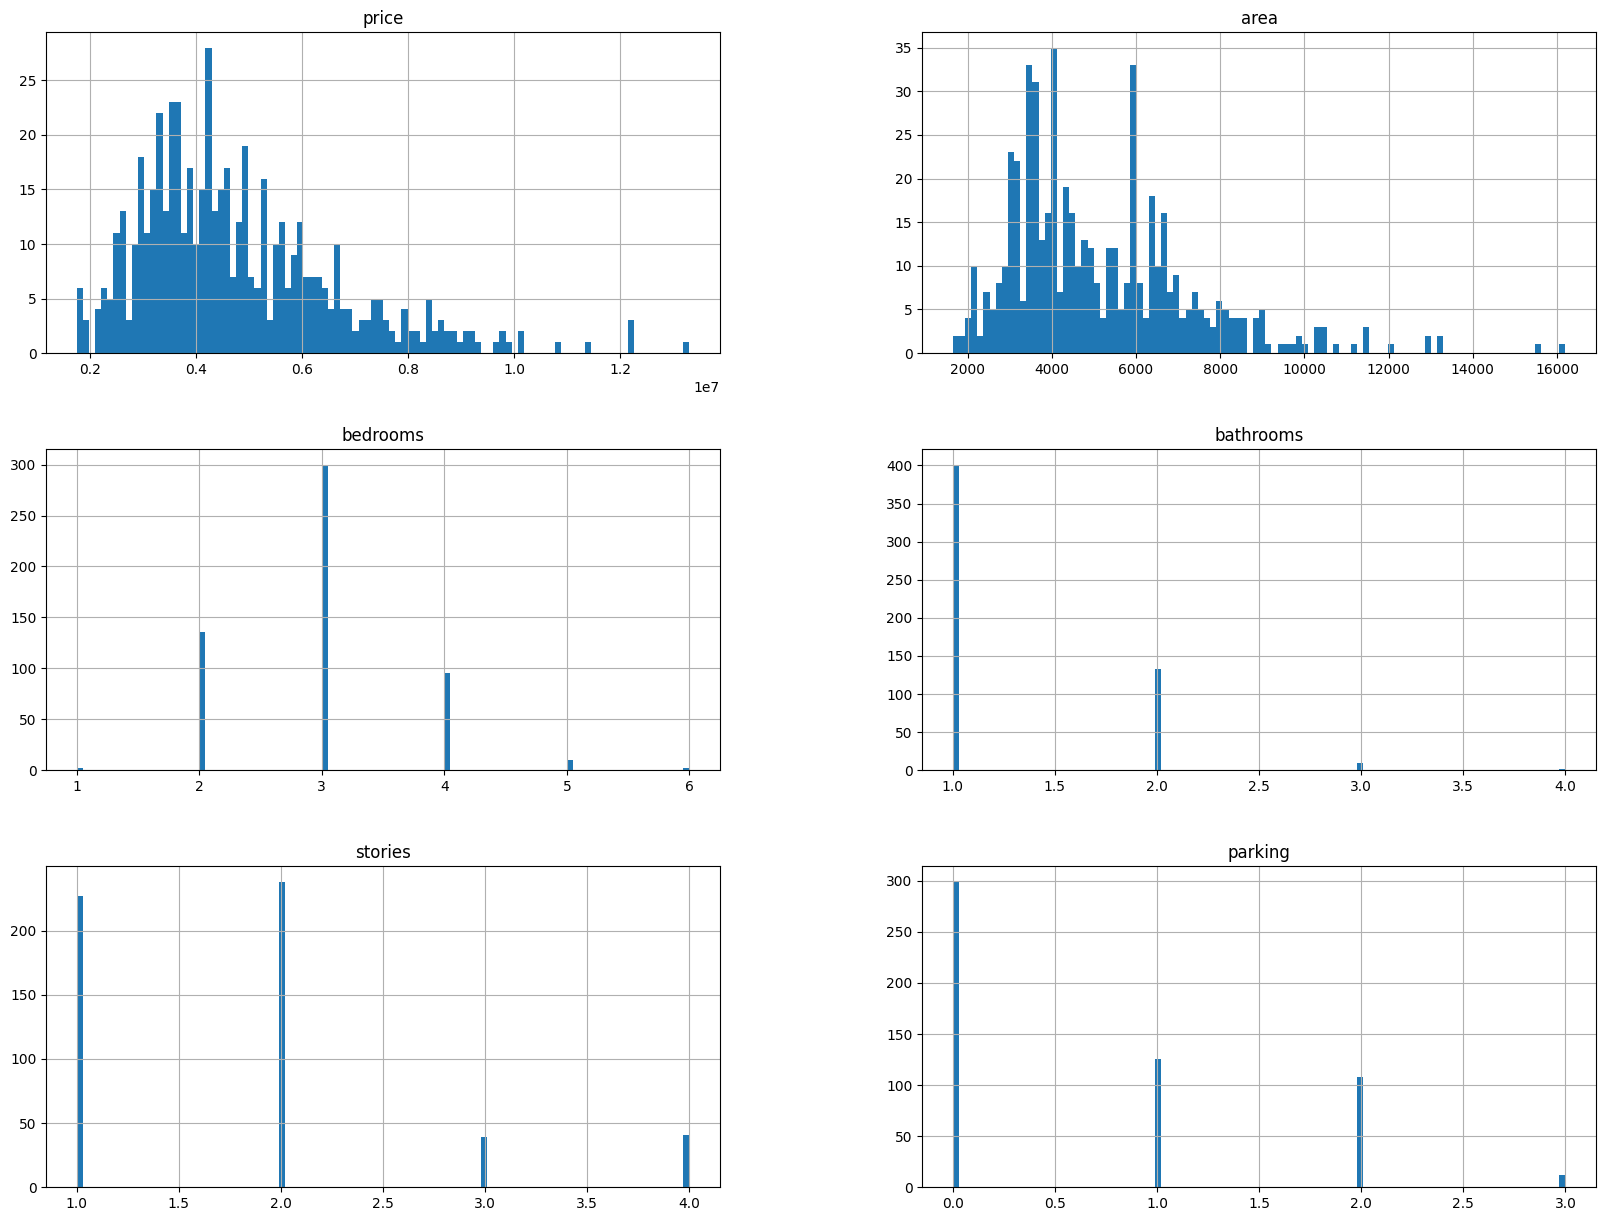

In [20]:
#let's plot the int columns and observe them
df.hist(bins=100, figsize=(20, 15))
#personally for me, histograms of price and area resamble the Poisson distribution, especially price columns

In [21]:
#let's verify the correlations of the columns in the dataset
numeric_cols = df.select_dtypes(include=["int64"]).columns.tolist()
corr_matrix = df[numeric_cols].corr()
corr_matrix["price"].sort_values(ascending=False)
#seems that price is quite correlated with the area and the number of bathrooms

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64

<Axes: xlabel='area', ylabel='price'>

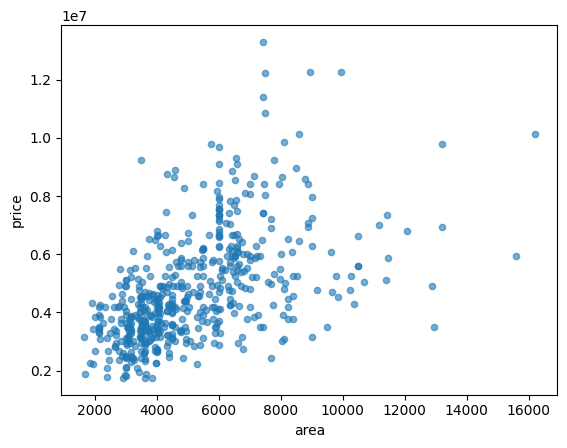

In [22]:
#a scatter plot of the area-to-price would be a handy thing for visualization
df.plot(kind="scatter", x="area", y="price", alpha=0.6)

array([[<Axes: xlabel='price', ylabel='price'>,
        <Axes: xlabel='area', ylabel='price'>,
        <Axes: xlabel='bedrooms', ylabel='price'>,
        <Axes: xlabel='bathrooms', ylabel='price'>,
        <Axes: xlabel='stories', ylabel='price'>,
        <Axes: xlabel='parking', ylabel='price'>],
       [<Axes: xlabel='price', ylabel='area'>,
        <Axes: xlabel='area', ylabel='area'>,
        <Axes: xlabel='bedrooms', ylabel='area'>,
        <Axes: xlabel='bathrooms', ylabel='area'>,
        <Axes: xlabel='stories', ylabel='area'>,
        <Axes: xlabel='parking', ylabel='area'>],
       [<Axes: xlabel='price', ylabel='bedrooms'>,
        <Axes: xlabel='area', ylabel='bedrooms'>,
        <Axes: xlabel='bedrooms', ylabel='bedrooms'>,
        <Axes: xlabel='bathrooms', ylabel='bedrooms'>,
        <Axes: xlabel='stories', ylabel='bedrooms'>,
        <Axes: xlabel='parking', ylabel='bedrooms'>],
       [<Axes: xlabel='price', ylabel='bathrooms'>,
        <Axes: xlabel='area', ylabel='b

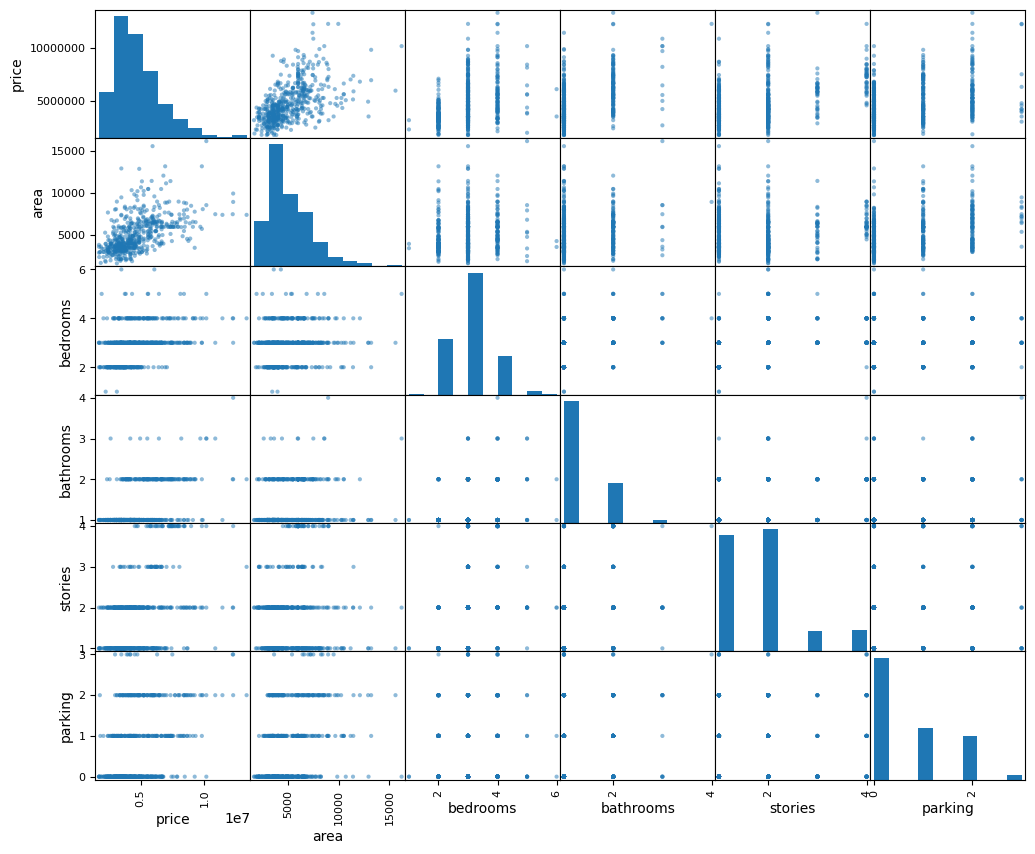

In [23]:
from pandas.plotting import scatter_matrix
#given that the majority of int columns are of a very narrow range, their scattered plots are quite useless 
scatter_matrix(df[numeric_cols], figsize=(12,10))